# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☐ Standard Analysis ☐ Research-Oriented  
**Group members:**  
- Mads Pagh
- Marcus Mofjeld

**Dataset:**  Spotify Playlists

**Initial task description (Module 1 perspective):**

We propose a project that critiques and expands upon the methodology presented in "Towards a Context-Aware Music
Recommendation Approach: What is Hidden in the Playlist Name?" [CITE]. The original authors demonstrated that
clustering playlist names to infer "listening contexts" can increase recommendation precision by 33% compared to
traditional collaborative filtering. However, their approach relied exclusively on k-means clustering. Our analysis goal
in this first part is Structure Discovery, specifically investigating the intrinsic geometry of these "listening contexts."
As noted in the course material, k-means is a Representative-based algorithm that assumes clusters are spherical,
compact, and distinct. We hypothesize that human-generated musical contexts are likely complex, arbitrary in shape,
and potentially nested, which makes the rigid partitioning of k-means a limitation. To test this, we will compare
the k-means baseline against alternative clustering paradigms: Subspace Clustering and Hierarchical Clustering. By
comparing these techniques, we aim to determine which structural definition best captures the semantic reality of user
playlists.

## 0. Reproducibility and Setup

In [2]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: https://www.kaggle.com/datasets/andrewmvd/spotify-playlists
- Number of instances: 12,902,045
- Number of features / entities: 4
- Missing values: 0
- Basic statistics:
Unique Users:            15,918
Unique Tracks:           2,036,899
Unique Raw Playlists:    157,530


In [3]:
from preprocessing.preprocessor import load_and_heal_data

# Load dataset (dataframe)
df = load_and_heal_data()

In [4]:
# View the first few rows of the dataframe
df.head()

,user_id,artistname,trackname,playlistname,homogenized_playlist
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010,hard rock 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010,hard rock 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010,hard rock 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010,hard rock 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010,hard rock 2010


### Preprocessing
Our preprocessing pipeline aims to match and improve upon that of [CITATION?]. The pipeline consists of the following main steps on the playlist names column:
#### Homogenization 
Homogenization is the process of extracting the base form (lemma) of a word. The process consists of two main steps. Firstly we use regular expressions to make all letters lowercase and strip out punctuation. Next we break all the words in the names into tokens and lemmatize them (e.g., converting "workouts" to "workout"). Practically this is done using the Natural Language Toolkit (NLTK) library. The aim with this process is to transform the messy inconsistent user-generated names into a standard format, which makes string matching more accurate in the clustering algorithms.

In [5]:
from preprocessing.preprocessor import homogenize_playlists
df = homogenize_playlists(df)

Column 'homogenized_playlist' already exists. Skipping homogenization.


#### Entity Filtering
The goal of entity filtering is to remove playlists that lack contextual information, or are strictly based on named entities (like specific artists, or bands). As we are trying to cluster based on the context described in the name, we filter out these non-contextual playlists to ensure our clustering models learn situational patterns rather than grouping artist discographies together.

To do this we run a strict filtering process, where we compare the playlist names against the artists present in the dataset, along with a set of predefined genres. To take it one step further, we use the spaCy NLP library to analyze the grammatical structure for further named entity recognition. The model looks for entities tagged as "person", "org" or "work of art", and removes playlists where this consists of 80% or more of the name. We also implement a "rescue mechanism", in which the script checks tokens for adjectives or verbs and ensures these playlists are kept, as the presence of an action or description implies context, regardless of the rest of the name.

In [6]:
from preprocessing.preprocessor import filter_entities
df = filter_entities(df)


[INFO] 'spotify_fully_processed.parquet' already exists. Loading it directly...


#### Stop-word Filtering
Stop-word filtering removes the words, which we do not want to expand and cluster on. Stop words define any words that are often used without providing semantic meaning. In our case we filter on both classic stop words such as "as" and "a" along with music specific stop words such as "track" and "playlist", which do not provide meaning to the playlist name. 

In [7]:
from preprocessing.preprocessor import remove_stop_words
df = remove_stop_words(df)


Stop words already filtered. Skipping.



#### Feature Expansion
The `expand_feature` function is responsible for the text preprocessing, which enriches the short strings, e.g. a playlist name, but appending related words to it. This technique provides more context for text-mining algorithms like TF-IDF. The flow of the function is the following:
1. First the input gets validated, an empty string is returned if not. 
2. A set is maintaned which stores the words, preventing duplicate entries. 
3. We then split the input strings into individual words and process them one by one. For each word, WordNet is used to find
    - Synonyms (Lemmas), which contain the exact same meaning. 
    - Hypernyms expanding general category words ('guitar' -> 'stringed instrument'). 
4. Lastly, the underscores from WordNet terms are replaced with spaces, and the final deduplicated set of original words, synonyms, and hypernyms is returned as a single, space-separated string. 

In [8]:
from preprocessing.preprocessor import expand_features
df = expand_features(df)


Expanded features already exist. Skipping expansion step.


### TF-IDF Creation and Analysis
We build and use a TF-IDF Matrix as a foundational data structure for our clustering algorithms. 

Term Frequency-Inverse Document Frequency (TF-IDF) is a statistical measure that evaluates how relevant a word is to a document within a larger collection by comparing local frequency to global rarity. Concretely, running the TfidfVectorizer transforms our preprocessed text data into a mathematical grid, where rows are the unique playlists, and our columns are the unique words present in all the names. The values in the matrix cells are scores representing the importance of a specific column's word to a specific row's playlist.

This representation allows for a mathematical translation of the strings in a format that supplies crucial context to the clustering models.
#### Building the TF-IDF
We will be using the TfidfVectorizer function from the sklearn library in tf-idf matrix creation.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

We care only for the entries that are flagged as being contextual from entity filtering, so we create a binary mask for further processing.

In [10]:
contextual_mask = df['is_contextual'] == True

Using the contextual mask we keep only the non-empty unique values from the expanded features column. 

In [11]:
unique_texts = df[contextual_mask]['expanded_features'].dropna().unique()

The imported function is called with parameters:
- min_df: This tells the vectorizer to completely ignore words that appear in fewer than 5 documents (playlists).
- max_df: Words appearing in more than 95% of the documents gets ignored too, this is because words that are extremely common across all playlists act as corpus-specific stop-words, i.e. if every playlist contained 'music' in their name, there would be no discriminative value to help seperate the playlists into distinct clusters. 
- max_features: We restrict the final vocabulary to contain only the top 5,678 most important features (words). The raw text data originally produced 24,712 unique features, following cumulative importance analysis we found that 80% of the information could be kept in the 5,678 top-most features, speeding up the clustering algorithms and dropping obscure words. 

Cumulative importance plot seen below, source-function (`plot_cumulative_importance`):

<img src="cum.png" width="500">

In [12]:
# Notice 5678 features maintaining 80% of the information.
vectorizer = TfidfVectorizer(min_df=5, max_df=0.95, max_features=5678)
tfidf_matrix = vectorizer.fit_transform(unique_texts)

## 2. Module 1 - Clustering Methods 
### K-Means (The Paper's Baseline)
K-Means was the method utilized in (CITE?). We decided to implement this approach to set a baseline we could compare
directly to the original authors’ findings. K-Means requires a predefined number of clusters, k, which we found
analyzing the gradient of the Within-Cluster Sum of Squares (WCSS), as the original authors did. By applying K-Means, we partition the full-dimensional space
spherical clusters, serving as our standard geometric baseline.

#### WCSS And Finding the Optimal K
To determine the optimal number of clusters ($k$) for our dataset, we employed a quantitative extension of the traditional Elbow Method. Rather than relying solely on a visual inspection of the Within-Cluster Sum of Squares (WCSS) curve, we analyzed the discrete derivative, or Delta WCSS, to identify statistically significant reductions in variance. By establishing statistical thresholds for variance reduction, this approach provides a more rigorous, data-driven foundation for our final cluster selection than visual estimation alone.

In [13]:
import os # comment
import glob # comment
from IPython.display import Image, display # comment
from clustering.kmeans.WCSS.WCSS import calculate_and_graph_wcss

We will be building the WCSS graphs and find the optimal $k$ based on that. 

WCSS graphs already exist in 'clustering/kmeans/WCSS'. Skipping heavy calculation.



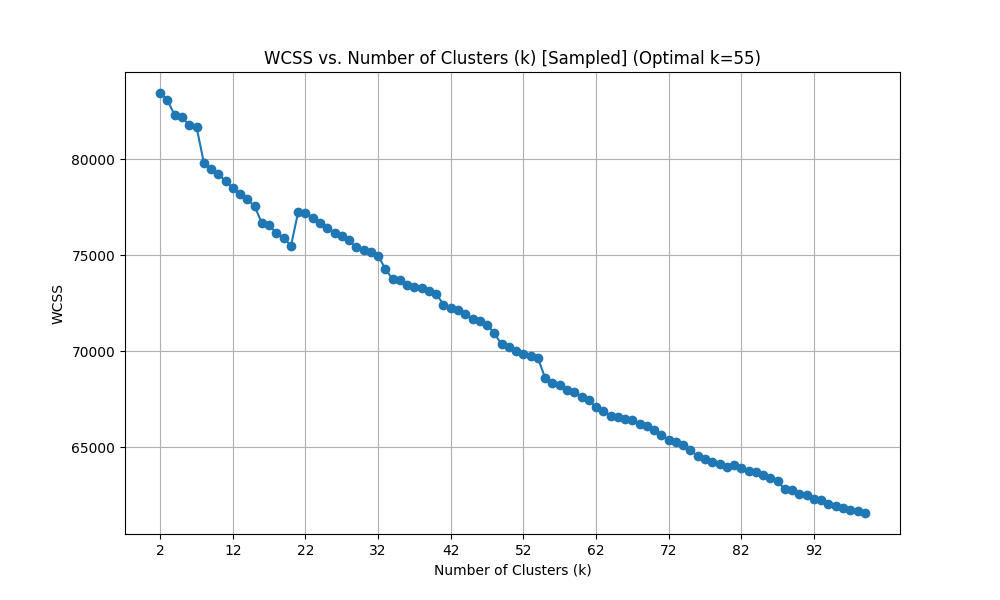

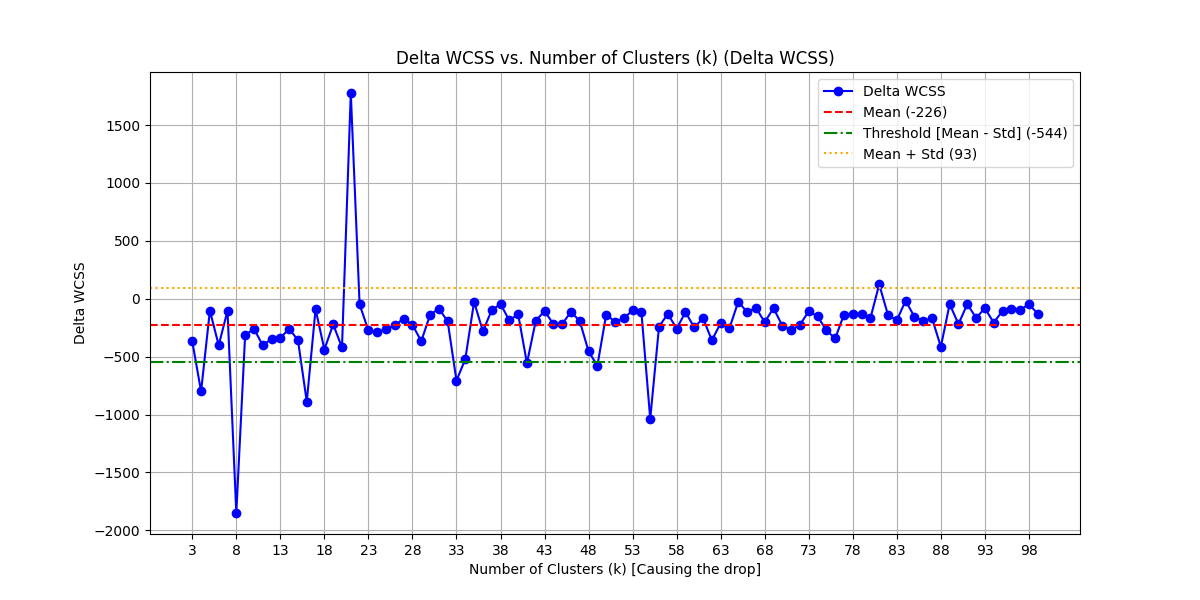


Loaded previously calculated optimal K: 55


In [14]:
wcss_dir = "clustering/kmeans/WCSS"
os.makedirs(wcss_dir, exist_ok=True)

# Search for any file ending in .png in the directory
wcss_pngs = glob.glob(os.path.join(wcss_dir, "*.png"))

optimal_k = 55 # FALLBACK
optimal_k_file = os.path.join(wcss_dir, "optimal_k.txt")

if not wcss_pngs:
    print(f"No WCSS graphs found in '{wcss_dir}'. Running WCSS to find optimal K...")
    
    # Run the heavy calculation
    calculated_k = calculate_and_graph_wcss(tfidf_matrix=tfidf_matrix)
    
    if calculated_k:
        optimal_k = calculated_k
        # Save this number to a text file so we remember it for the next run!
        with open(optimal_k_file, "w") as f:
            f.write(str(optimal_k))
else:
    print(f"WCSS graphs already exist in '{wcss_dir}'. Skipping heavy calculation.\n")
    
    # Display the found images directly in the Jupyter Notebook
    for img_path in wcss_pngs:
        display(Image(filename=img_path))
        
    # Try to load the previously saved optimal K
    if os.path.exists(optimal_k_file):
        with open(optimal_k_file, "r") as f:
            optimal_k = int(f.read().strip())
        print(f"\nLoaded previously calculated optimal K: {optimal_k}")
    else:
        print(f"\nNo saved K value found. Defaulting to K={optimal_k}")

#### Analysis of the WCSS Trajectory
The primary WCSS analysis demonstrates the expected overall decrease in total intra-cluster variance as the number of clusters increases. Notably, an anomaly was observed around k=21, where the WCSS exhibited a sharp, positive spike. Because standard K-Means optimization typically results in a monotonic decrease or plateauing of WCSS, this spike indicates that the algorithm likely encountered poor local minima during initialization or was impacted by the specific data sampling technique utilized. Despite this localized instability, the broader trajectory of the data remains intact and provides a clear baseline for evaluating cluster performance.
#### Evaluating Variance Reductions (Delta WCSS)
To isolate the exact point of diminishing returns, we examined the sequential change in variance using the Delta WCSS metric. A statistical significance threshold was established at one standard deviation below the mean change in variance (a drop of -544). While the earliest cluster additions particularly at k=8 yielded the most dramatic absolute reductions in variance, these initial drops generally represent only the highest-level, most obvious separations in the data. Our goal was to capture all meaningful subgroupings without overfitting.

Our analysis reveals that k=55 marks the final major, statistically significant drop in variance that crosses our established threshold. Beyond this point, variance reductions rapidly flatten and hover near the mean, indicating the onset of diminishing returns. By selecting k=55 as the optimal number of clusters, our model prioritizes a highly granular structure, ensuring that all significant, underlying patterns within the data are captured effectively.

### K-Means Execution

In [15]:
from clustering.kmeans.kmeans_clustering import KMeansClustering

In [16]:
KMeans = KMeansClustering(k=55, max_iter=300, n_init=10, random_state=RANDOM_SEED)

target_col = getattr(KMeans, "cluster_col", None)
report_out = KMeans.report_dir

print(f"Checking for: '{target_col}' in columns: {df.columns.tolist()[:10]}...")
if target_col in df.columns:
    print(f"\n[SKIP] {KMeans.algo_name} already exists in column '{target_col}'.")
else:
    print(f"\n{'='*50}")
    print(f"Executing Pipeline for: {KMeans.algo_name}")
    print(f"{'='*50}")

    df, target_col = KMeans.run_pipeline(df, unique_texts, tfidf_matrix)
    KMeans.create_report()

    if target_col and target_col in df.columns:
        from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
        print(f"[INFO] Saving updated labels to {FULLY_PROCESSED_PARQUET}...")
        df.to_parquet(FULLY_PROCESSED_PARQUET, index=False)

Checking for: 'k-means_cluster_55' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] KMeans already exists in column 'k-means_cluster_55'.


### Clustering Evaluation


[INFO] Evaluation Metrics for 'k-means_cluster_55':
=== Evaluation Results for k-means_cluster_55 ===
Total Clusters Evaluated: 54

Top-1 Average  : [np.float64(0.6906), np.float64(0.684), np.float64(0.6756), np.float64(0.6588), np.float64(0.6297)]
Top-5 Average  : [np.float64(0.649), np.float64(0.6488), np.float64(0.6414), np.float64(0.6257), np.float64(0.5806)]
Top-10 Average : [np.float64(0.6045), np.float64(0.6047), np.float64(0.5948), np.float64(0.5792), np.float64(0.5338)]
Top-all Average: [np.float64(0.3359), np.float64(0.3316), np.float64(0.3231), np.float64(0.3124), np.float64(0.2827)]



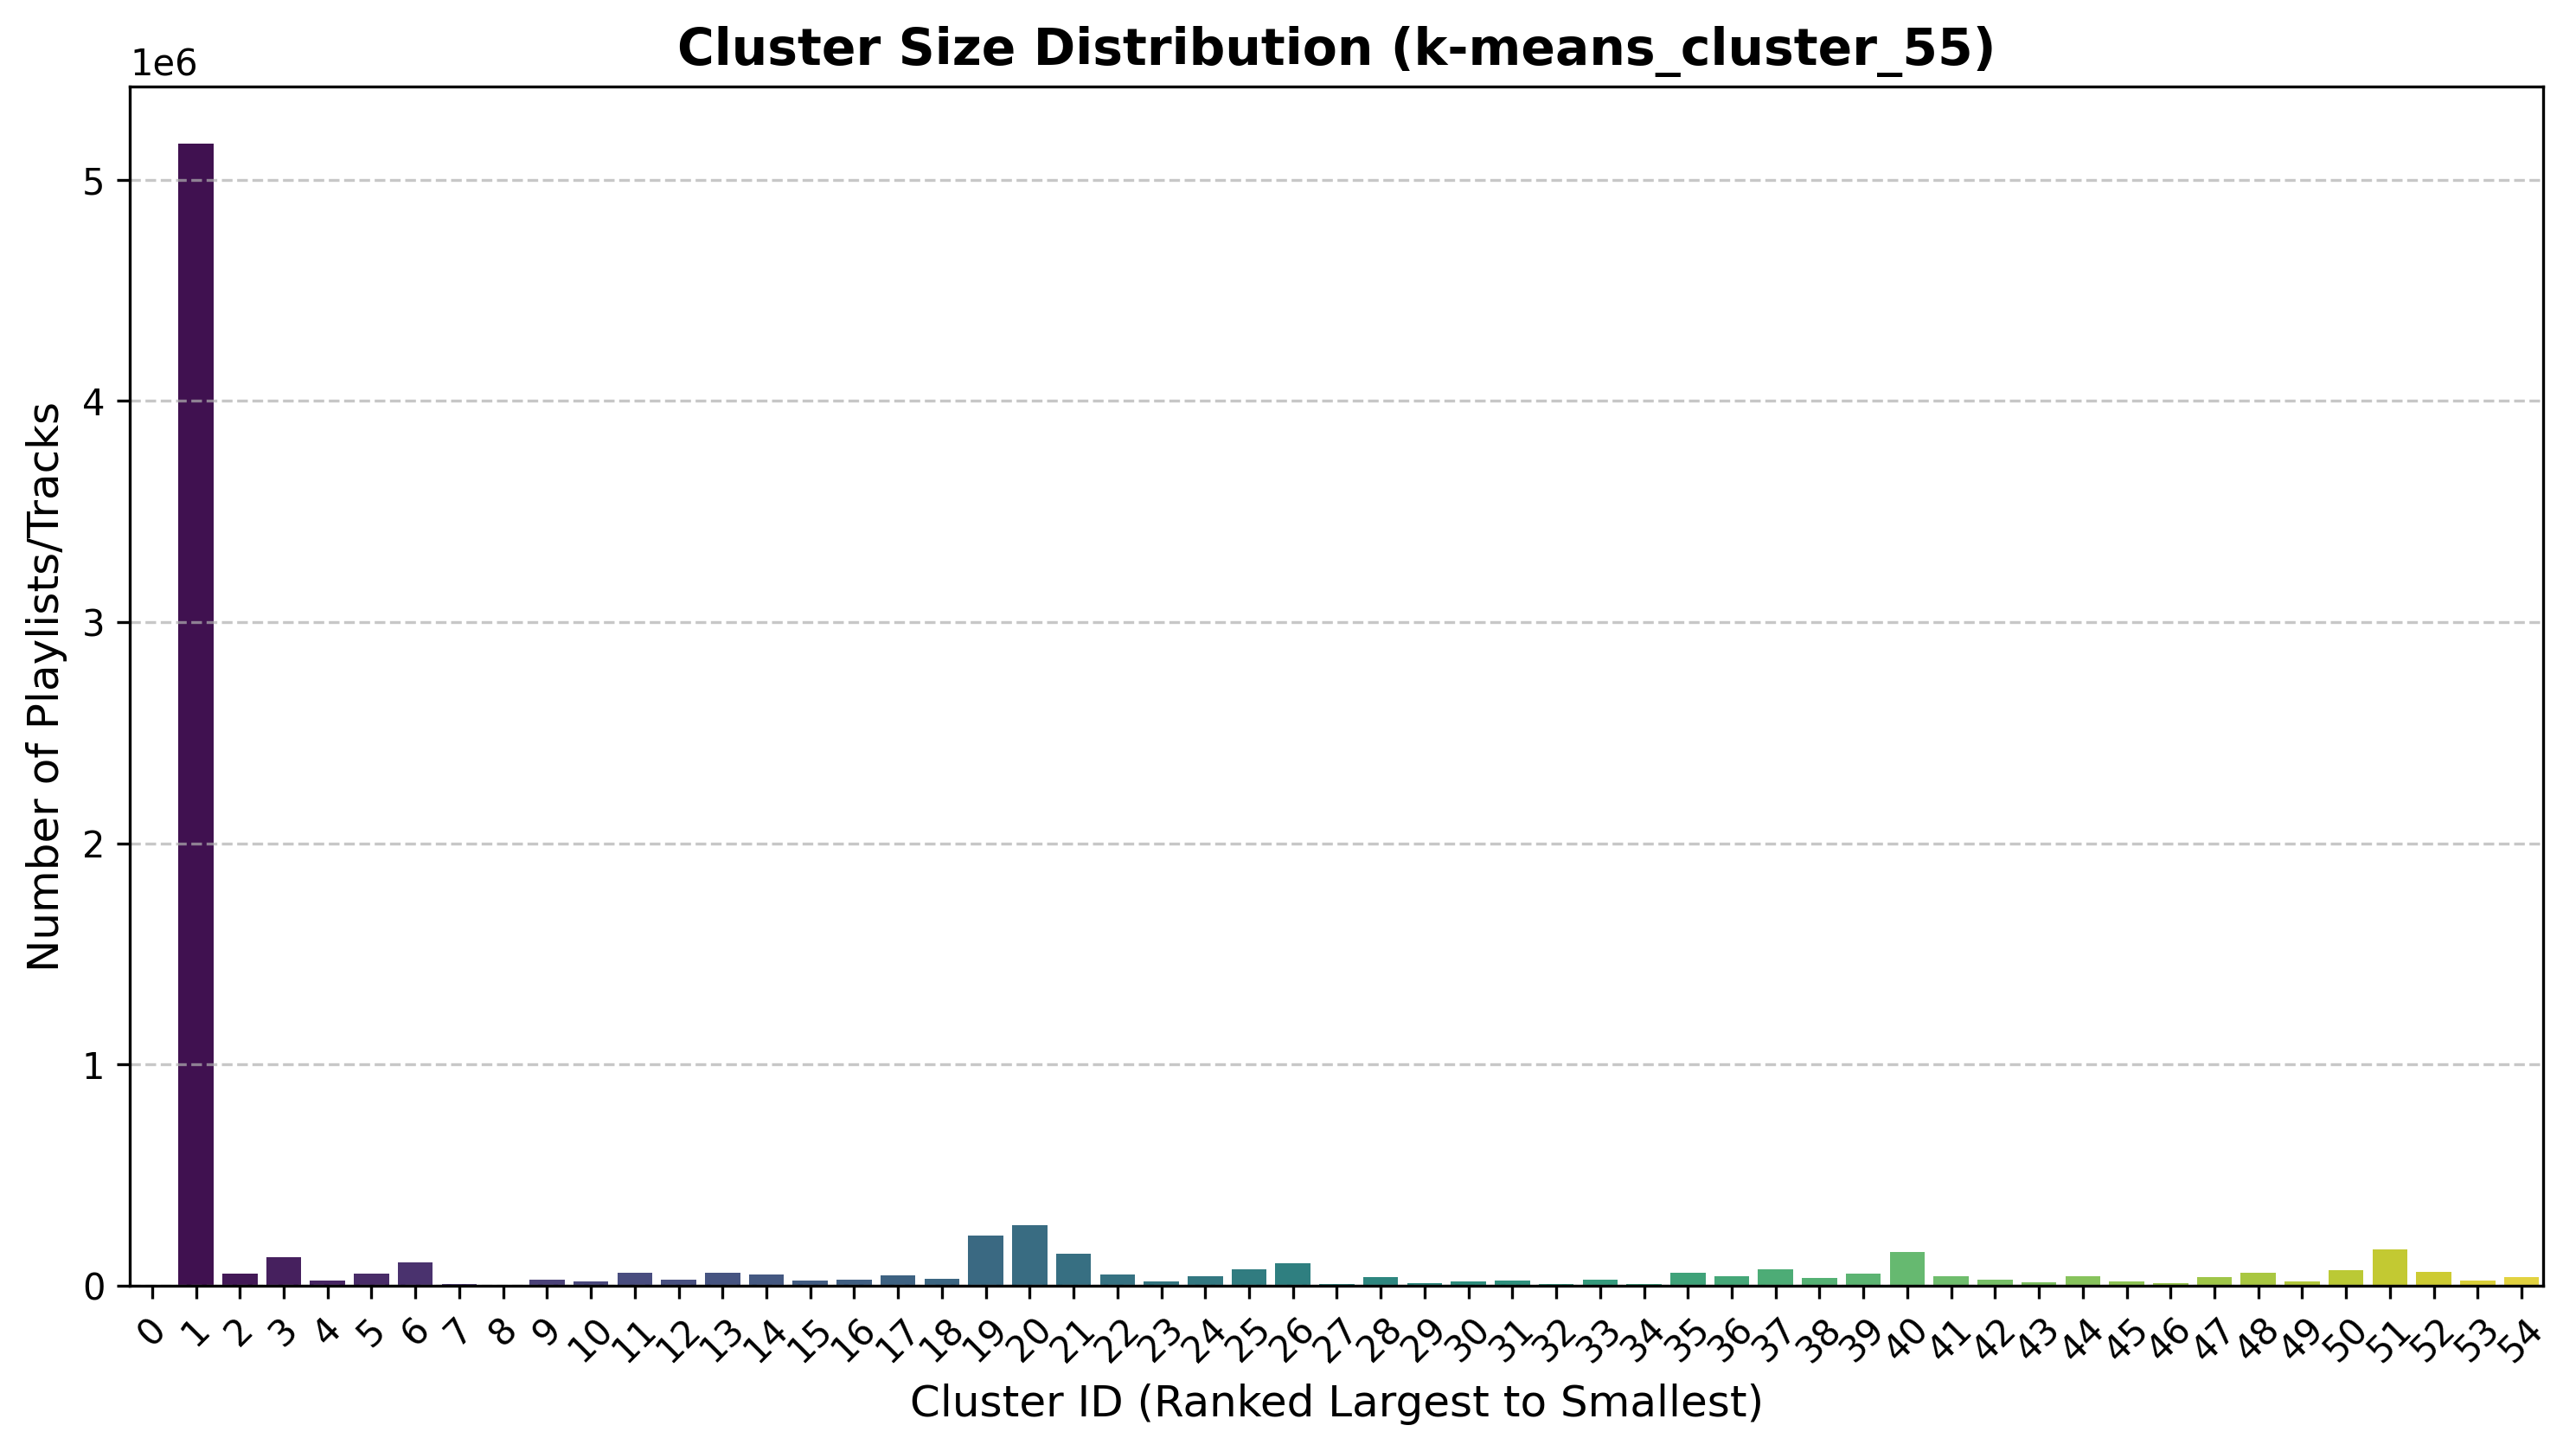

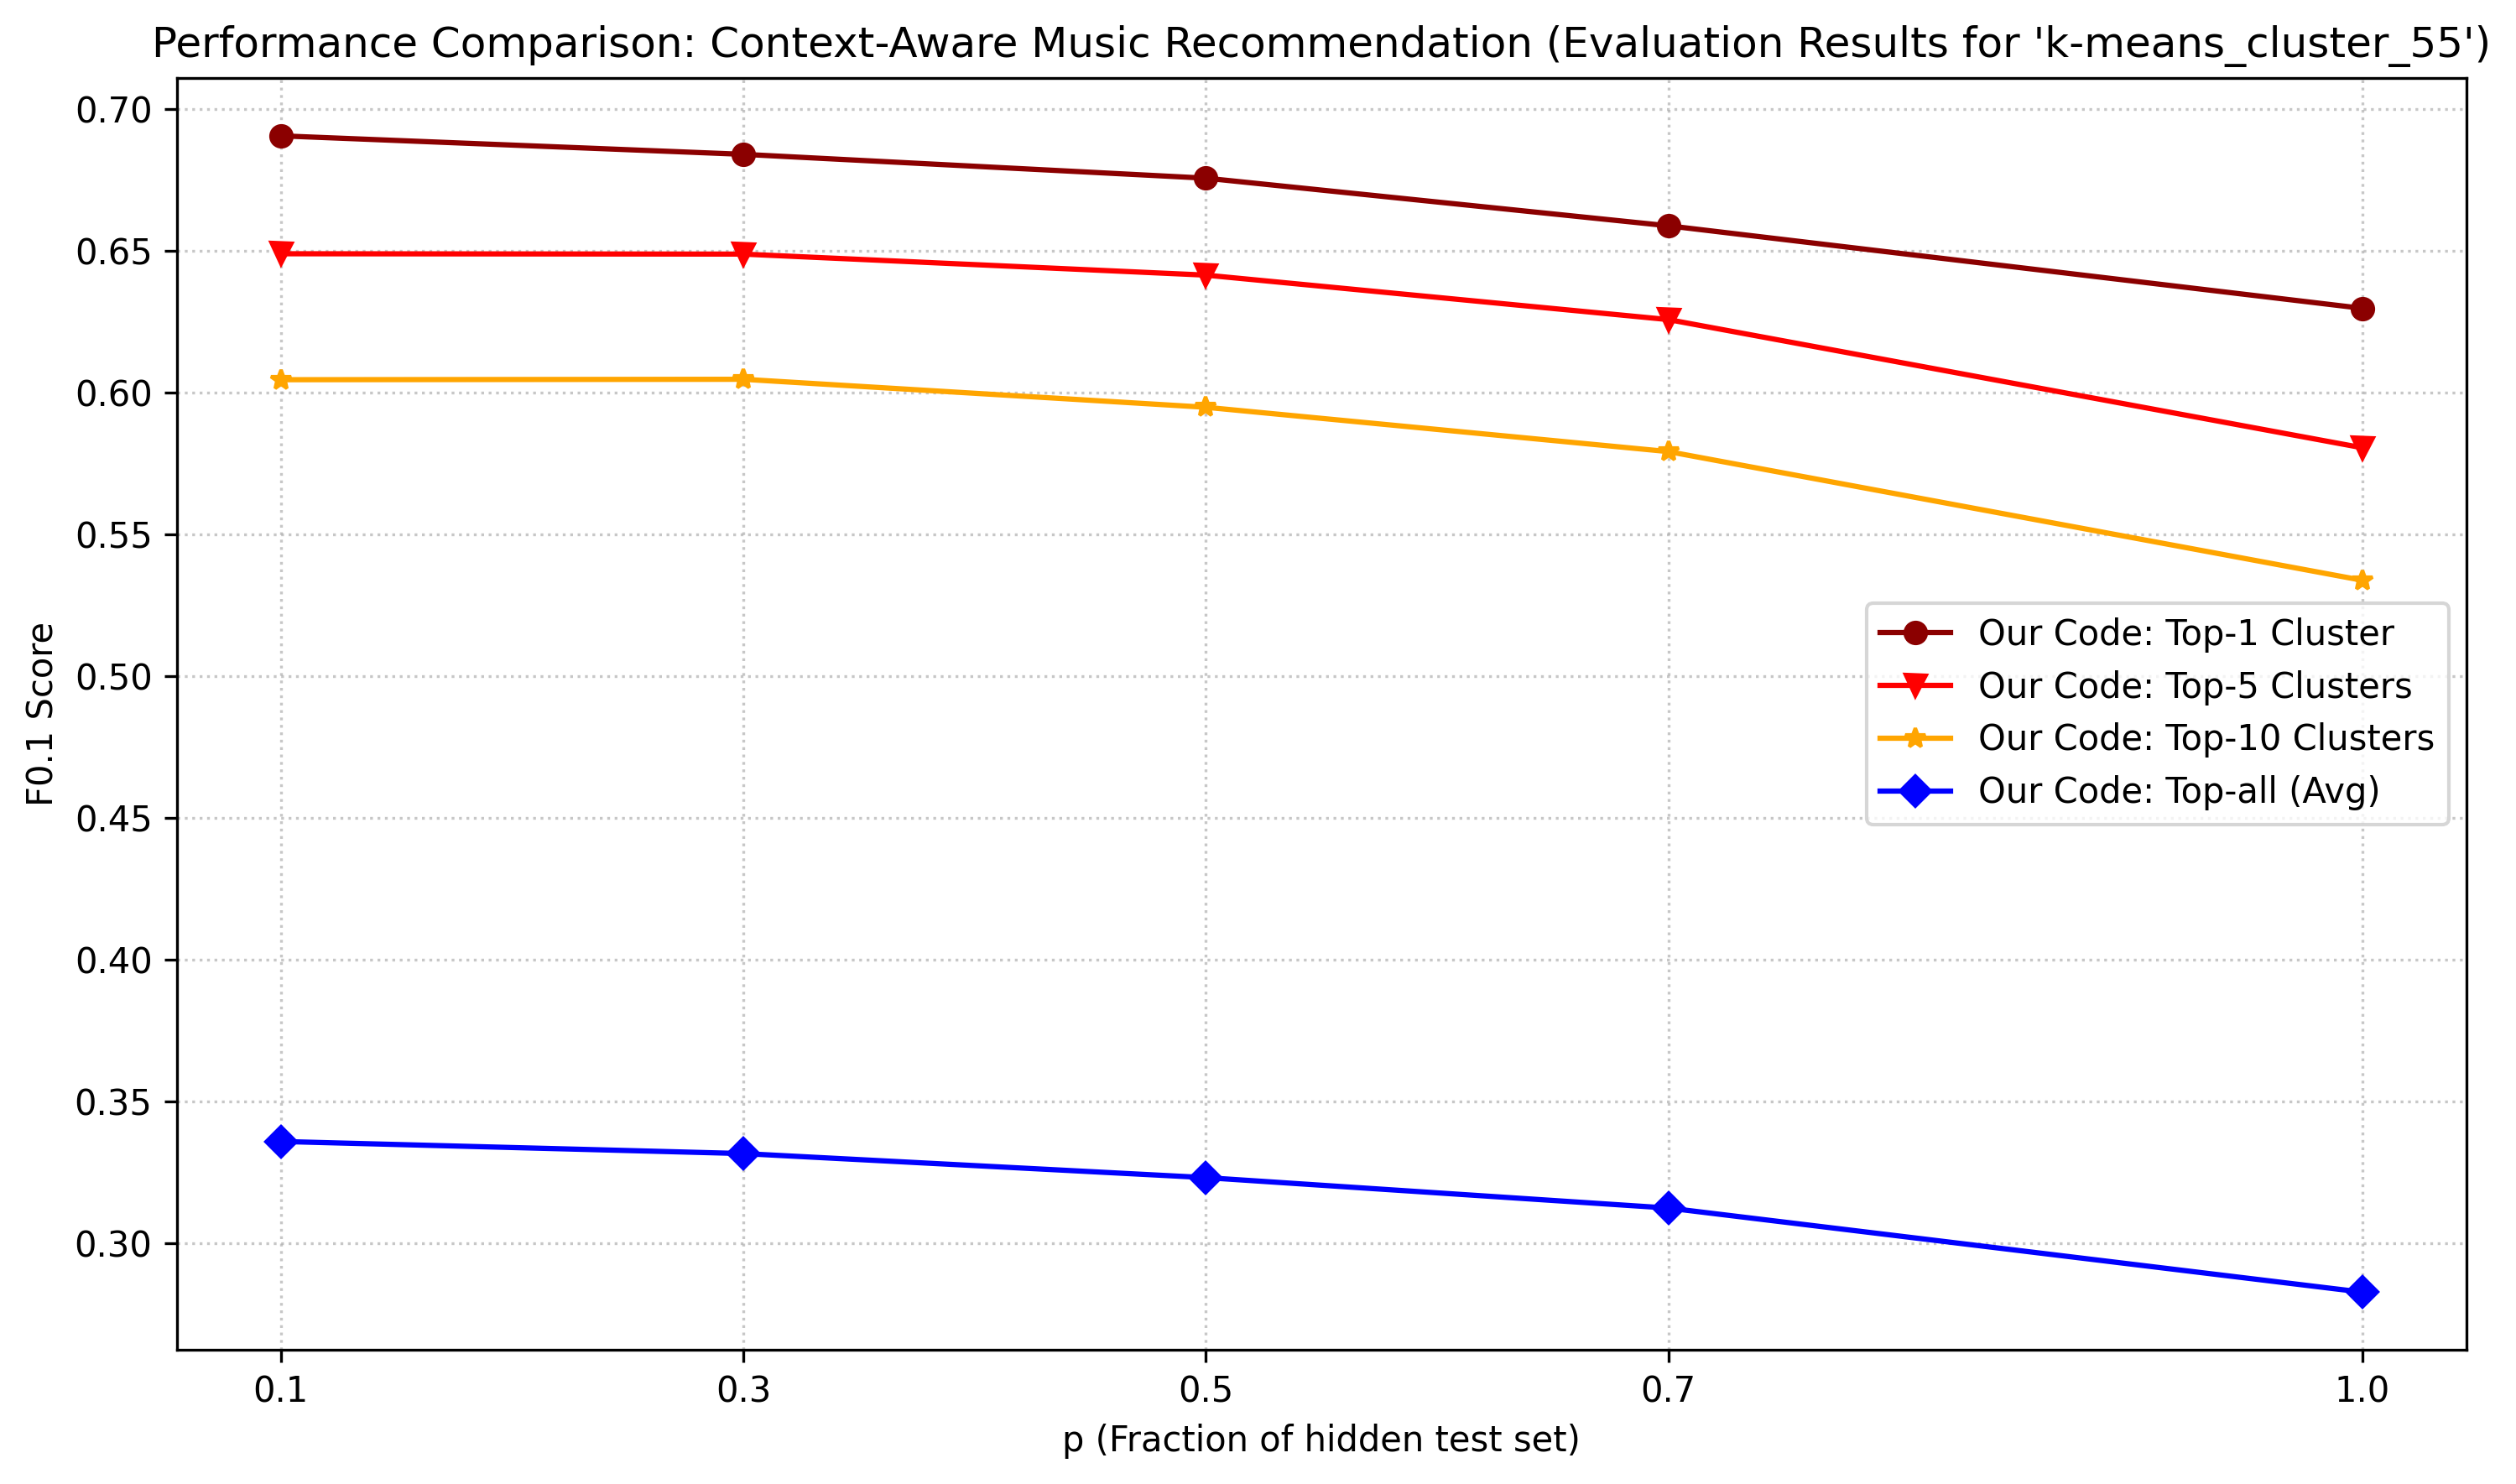

In [21]:
from evaluation.evaluator import eval
# Safety check
if target_col in df.columns:
    os.makedirs(report_out, exist_ok=True)
    eval_report_path = os.path.join(report_out, f"evaluation_metrics_{target_col}.txt")
    # If eval exists, read and print it. Otherwise, create a placeholder.
    if os.path.exists(eval_report_path):
        with open(eval_report_path, "r") as f:
            eval_content = f.read()
        print(f"\n[INFO] Evaluation Metrics for '{target_col}':\n{eval_content}")
        # Load and display the two evaluation graphs, exists as pngs in the report_out directory
        cdist = os.path.join(report_out, f"cluster_distribution.png")
        f01 = os.path.join(report_out, f"f01_comparison.png")
        if os.path.exists(cdist):
            display(Image(filename=cdist))
        if os.path.exists(f01):
            display(Image(filename=f01))
    else:
        print(f"\n[INFO] Starting evaluation for '{target_col}'...")
        eval(df=df,
             cluster_col=target_col,
             unique_texts=unique_texts,
             tfidf_matrix=tfidf_matrix,
             sample_frac=0.1,
             output_dir=report_out)

### Birch (Hierachical Clustering)
To address the potential limitations of K-Means’ rigid, global partitioning, we implemented BIRCH (Balanced Iterative
Reducing and Clustering using Hierarchies).

BIRCH operates in two distinct phases that structurally mirror the nested nature of music (e.g., sub-genres). 
Playlists are processed incrementally, constructing a specialized data structure called a Clustering Feature (CF) Tree. Data points are summarized into CFs which represent a tightly packed sphere of points. If a playlist vector falls within the radius of an existing sphere, it is absorbed into that sphere, if it doesn't, a new CF is created. This creates clusters, but not necessarily $k$. Therefore an agglomerative hierarchical clustering algorithm is run on the centroids marge the closest pairs until there are $k$ clusters.

K-Means is known to be
sensitive to noise, often letting outliers/noise pull centroids off center, as they’re forced to assign every point to a cluster. The bottom-up approach of BIRCH ensures that the final macro-clusters are built from pure semantic building blocks
rather than forced global averages. Furthermore, the final agglomerative merge allows for non-spherical clusters, unlike
k-means. By finding clusters from highly specific sub-contexts, BIRCH allows us to test if a hierarchical structural
definition better captures the semantic reality of human musical curation.

To implement BIRCH we instantiate the sklearn.cluster.Birch model with three hyperparameters.
 - k=55: The amount of desired clusters. Derived from WCSS, chosen such that we can compare results with K-means.
 - Thereshold=0.9: Controls the maximum radius of a sub-cluster. As our TF-IDF matrix creates a high-dimensional sparse space, the points will naturally be far apart. A threshold of 0.9 aims to be forgiving enough to group slight varying text structures (e.g., "workout mix" and "gym playlist"), while still separating distinct broader contexts.
 - Branching Factor=25: Defines the width limit of the tree. 25 was chosen as a moderates alternative to the default 50, which aims to mirror the deeply nested music taxonomy. 
We thereafter call the fit and predict methods, corresponding to the aforementioned process.

## 3. Module 2 — Graph-Based Analysis

In [18]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [19]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
